<div style="background-color:#1F3864; color:white; padding:20px; border-radius:8px;">
<h1 style="margin:0; color:white;"><b>CRISP-DM: Predicción de Lluvia en Australia</b></h1>
<h3 style="margin:5px 0 0 0; color:#BDD7EE;"><b>BIY7121 — Minería de Datos | DuocUC, Escuela de Informática y Telecomunicaciones</b></h3>
<h3 style="margin:5px 0 0 0; color:#BDD7EE;"><b>Prueba 2: Aplicando la metodología CRISP-DM</b></h3>
</div>

---

## **Equipo de Trabajo**

| Integrante | Rol |
|------------|-----|
| Julian Tapia | Estudiante |
| Benjamin Herrera | Estudiante |

**Dataset:** weatherAUS.csv — Datos meteorológicos de Australia.

                "import os",
                "import sys",
                "import locale",
**Variable objetivo:** RainTomorrow (¿Lloverá mañana?)
                "",
                "# Forzar UTF-8 para evitar errores de decodificación en subprocess en Windows",
                "os.environ.setdefault('PYTHONUTF8', '1')",
                "os.environ.setdefault('PYTHONIOENCODING', 'utf-8')",
                "if hasattr(sys.stdout, 'reconfigure'):",
                "    sys.stdout.reconfigure(encoding='utf-8')",
                "if hasattr(sys.stderr, 'reconfigure'):",
                "    sys.stderr.reconfigure(encoding='utf-8')",
                "try:",
                "    locale.getpreferredencoding = lambda do_setlocale=False: 'UTF-8'",
                "except Exception:",
                "    pass",

**Metodología:** CRISP-DM (Cross-Industry Standard Process for Data Mining)

**Nota:** Este notebook usa TODOS los registros del dataset (~142,000) para el análisis completo.

---

---

## 📖 Glosario para Lectores No Técnicos

| Término | Significado Simple |
|---------|-------------------|
| **Dataset** | Archivo con datos (como una hoja de Excel) |
| **Feature / Variable** | Una columna en los datos, como "Humedad" o "Temperatura" |
| **Modelo** | Una fórmula matemática que hace predicciones |
| **Entrenar** | Enseñar al modelo con datos históricos |
| **Test / Prueba** | Verificar que el modelo funciona con datos nuevos |
| **Accuracy** | De 100 predicciones, cuántas fueron correctas |
| **Precision** | De las veces que dijimos "lloverá", cuántas realmente llovieron |
| **Recall** | De las veces que realmente llovió, cuántas predijimos |
| **Overfitting** | Cuando el modelo memoriza en lugar de aprender realmente |
| **Clustering** | Agrupar datos automáticamente sin saber las respuestas |

### ¿Cómo funciona cada modelo? (Analogías simples)

- **Naive Bayes**: Como un médico que pregunta síntomas y da un diagnóstico basado en probabilidades
- **Regresión Logística**: Como una regla simple tipo "si X > 50, entonces llueve"
- **Árbol de Decisión**: Como un juego de "20 preguntas" para llegar a la respuesta
- **Random Forest**: Como un equipo de 100 expertos votando, se toma la mayoría
- **K-Means**: Como dividir personas en 3 grupos según sus similitudes

## ¿Qué es este proyecto? (Para quienes no saben de Ciencia de Datos)

Este proyecto usa **Machine Learning** (aprendizaje automático) para responder una pregunta simple: "¿Lloverá mañana?"

Imagina que le enseñas a un niño a reconocer patrones del clima. Le das muchos ejemplos: "cuando hay muchas nubes y alta humedad, usualmente llueve". Con el tiempo, el niño aprende a predecir. Este proyecto hace lo mismo pero con una computadora.

**¿Por qué es importante?**
- Las minas australianas pierden dinero si no anticipan tormentas
- Los agricultores necesitan saber si regar o no sus cultivos
- Australia es el continente más seco, cada gota de agua cuenta

---

## **Índice**

1. [Fase 1: Entendimiento del Negocio](#1-fase-1-entendimiento-del-negocio)
2. [Fase 2: Entendimiento de los Datos](#2-fase-2-entendimiento-de-los-datos)
3. [Fase 3: Preparación de los Datos](#3-fase-3-preparacion-de-los-datos)
4. [Fase 4: Modelado](#4-fase-4-modelado)
5. [Bibliografía](#bibliografía)

## **1. Fase 1: Entendimiento del Negocio**

<span style="color:#2E75B6;">**Contexto del negocio:**</span> Australia es el continente más seco del mundo, con un 40% de su territorio formado por dunas de arena. El sector minero representa ~10% del PIB australiano con exportaciones por 299.000 millones AUD. La predicción meteorológica es crítica para:

- **Industria minera:** Las operaciones a cielo abierto y transporte de minerales dependen de las condiciones climáticas.
- **Agricultura:** Las zonas fértiles del southeast requieren planificación de riego.
- **Gestión de recursos hídricos:** El 65% del territorio carecen de corrientes de agua hacia el mar.

<span style="color:#2E75B6;">**Situación:**</span> Se dispone de un dataset con datos meteorológicos históricos de diversas localidades de Australia. El objetivo es predecir si lloverá mañana (`RainTomorrow`) basándose en las condiciones climáticas del día actual.

<span style="color:#2E75B6;">**Objetivos clave del proyecto:**</span>

| Objetivo | Descripción |
|----------|-------------|
| OBJ-1 | Predecir si lloverá mañana con recall ≥ 0,70 para la clase "Sí" |
| OBJ-2 | Identificar las variables meteorológicas más relevantes para la predicción |
| OBJ-3 | Proporcionar probabilidades interpretables para la toma de decisiones |

<span style="color:#2E75B6;">**Indicadores Clave de Desempeño (KPI):**</span>

| KPI | Meta | Justificación |
|-----|------|----------------|
| **Recall (Lloverá)** | ≥ 0,70 | Minimizar falsos negativos (no predecir lluvia cuando ocurrirá) es crítico para evitar costos en operaciones mineras y agrícolas |
| **Precisión** | ≥ 0,60 | Evitar falsas alarmas que generen alertas innecesarias |
| **F1-Score** | ≥ 0,55 | Balance entre precisión y recall |
| **Accuracy** | ≥ 0,80 | Métrica general del modelo |
| **AUC-ROC** | ≥ 0,75 | Capacidad discriminativa del modelo |

<span style="color:#2E75B6;">**Pregunta analítica:**</span> ¿puede un clasificador Naive Bayes predecir correctamente si lloverá mañana, alcanzando una *recall* ≥ 0,70 sobre la clase "Sí"?

<span style="color:#2E75B6;">**Justificación del método:**</span> Naive Bayes es apropiado porque:

(i) Es simple y rápido,

(ii) Entrega probabilidades posteriores interpretables,

(iii) Funciona bien con features numéricas aproximadamente gaussianas.

## **2. Fase 2: Entendimiento de los Datos**

<span style="color:#2E75B6;">**2.1 Descripción del dataset:**</span> El dataset `weatherAUS.csv` contiene registros meteorológicos diarios de múltiples ubicaciones en Australia, proporcionados por la Oficina de Meteorología de la Commonwealth australiana. La variable objetivo es `RainTomorrow` (¿Lloverá mañana? - Sí/No).

In [30]:
# --- Imports estándar de Minería de Datos ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, roc_curve
)

# --- Configuración institucional ---
SEMILLA = 42
COLOR_TITULO    = '#1F3864'
COLOR_DESTACADO = '#2E75B6'
COLOR_NEUTRO    = '#BFBFBF'

np.random.seed(SEMILLA)
pd.options.display.float_format = '{:,.4f}'.format

print('Entorno preparado correctamente. Semilla fijada en', SEMILLA)

Entorno preparado correctamente. Semilla fijada en 42


In [31]:
# --- Carga del dataset weatherAUS ---
df = pd.read_csv('weatherAUS.csv')

# Usamos TODOS los registros del dataset

print('Dimensiones del dataset:', df.shape)
print()
print('Columnas disponibles:')
print(df.columns.tolist())

Dimensiones del dataset: (142193, 24)

Columnas disponibles:
['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow']


<span style="color:#2E75B6;">**2.2 Análisis de tipos de datos:**</span> El dataset contiene **24 columnas** que se clasifican en:

| Tipo | Variables | Descripción |
|------|-----------|-------------|
| **Numéricas continuas** | MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustSpeed, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm, RISK_MM | Variables meteorológicas cuantitativas |
| **Categóricas** | Location, WindGustDir, WindDir9am, WindDir3pm, RainToday | Ubicación y direcciones del viento |
| **Fecha** | Date | Fecha de la observación |
| **Binaria** | RainTomorrow | Variable objetivo (Sí/No) |

In [32]:
# --- Análisis de tipos de datos ---
print('=== Tipos de datos ===')
print(df.dtypes)
print()
print('=== Resumen estadístico ===')
df.describe()

=== Tipos de datos ===
Date                 str
Location             str
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir          str
WindGustSpeed    float64
WindDir9am           str
WindDir3pm           str
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday            str
RISK_MM          float64
RainTomorrow         str
dtype: object

=== Resumen estadístico ===


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,"141,556.0000","141,871.0000","140,787.0000","81,350.0000","74,377.0000","132,923.0000","140,845.0000","139,563.0000","140,419.0000","138,583.0000","128,179.0000","128,212.0000","88,536.0000","85,099.0000","141,289.0000","139,467.0000","142,193.0000"
mean,12.1864,23.2268,2.3500,5.4698,7.6249,39.9843,14.0020,18.6376,68.8438,51.4826,"1,017.6538","1,015.2582",4.4372,4.5032,16.9875,21.6872,2.3607
std,6.4033,7.1176,8.4652,4.1885,3.7815,13.5888,8.8933,8.8033,19.0513,20.7978,7.1055,7.0367,2.8870,2.7206,6.4928,6.9376,8.4780
min,-8.5000,-4.8000,0.0000,0.0000,0.0000,6.0000,0.0000,0.0000,0.0000,0.0000,980.5000,977.1000,0.0000,0.0000,-7.2000,-5.4000,0.0000
25%,7.6000,17.9000,0.0000,2.6000,4.9000,31.0000,7.0000,13.0000,57.0000,37.0000,"1,012.9000","1,010.4000",1.0000,2.0000,12.3000,16.6000,0.0000
50%,12.0000,22.6000,0.0000,4.8000,8.5000,39.0000,13.0000,19.0000,70.0000,52.0000,"1,017.6000","1,015.2000",5.0000,5.0000,16.7000,21.1000,0.0000
75%,16.8000,28.2000,0.8000,7.4000,10.6000,48.0000,19.0000,24.0000,83.0000,66.0000,"1,022.4000","1,020.0000",7.0000,7.0000,21.6000,26.4000,0.8000
max,33.9000,48.1000,371.0000,145.0000,14.5000,135.0000,130.0000,87.0000,100.0000,100.0000,"1,041.0000","1,039.6000",9.0000,9.0000,40.2000,46.7000,371.0000


<span style="color:#2E75B6;">**2.3 Distribucion de variables numericas:**</span> Histogramas para visualizar la distribucion de las principales variables meteorologicas.

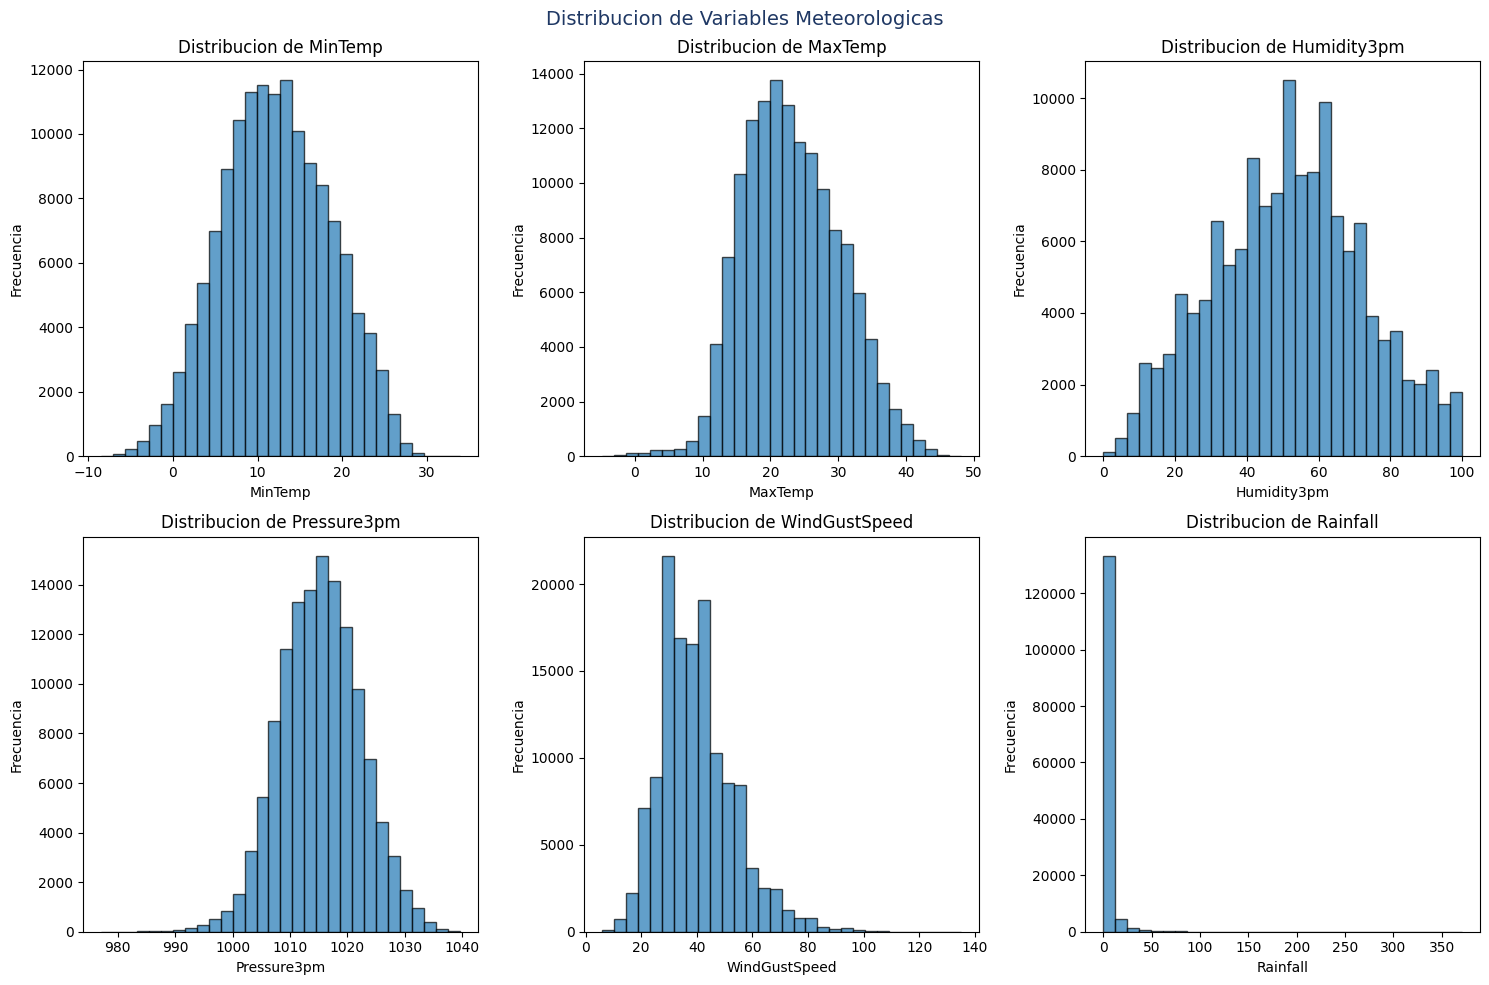

In [33]:
# Grafico de distribucion de las principales variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

vars_to_plot = ['MinTemp', 'MaxTemp', 'Humidity3pm', 'Pressure3pm', 'WindGustSpeed', 'Rainfall']

for i, col in enumerate(vars_to_plot):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title('Distribucion de ' + col, fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribucion de Variables Meteorologicas', fontsize=14, color=COLOR_TITULO)
plt.tight_layout()
plt.show()

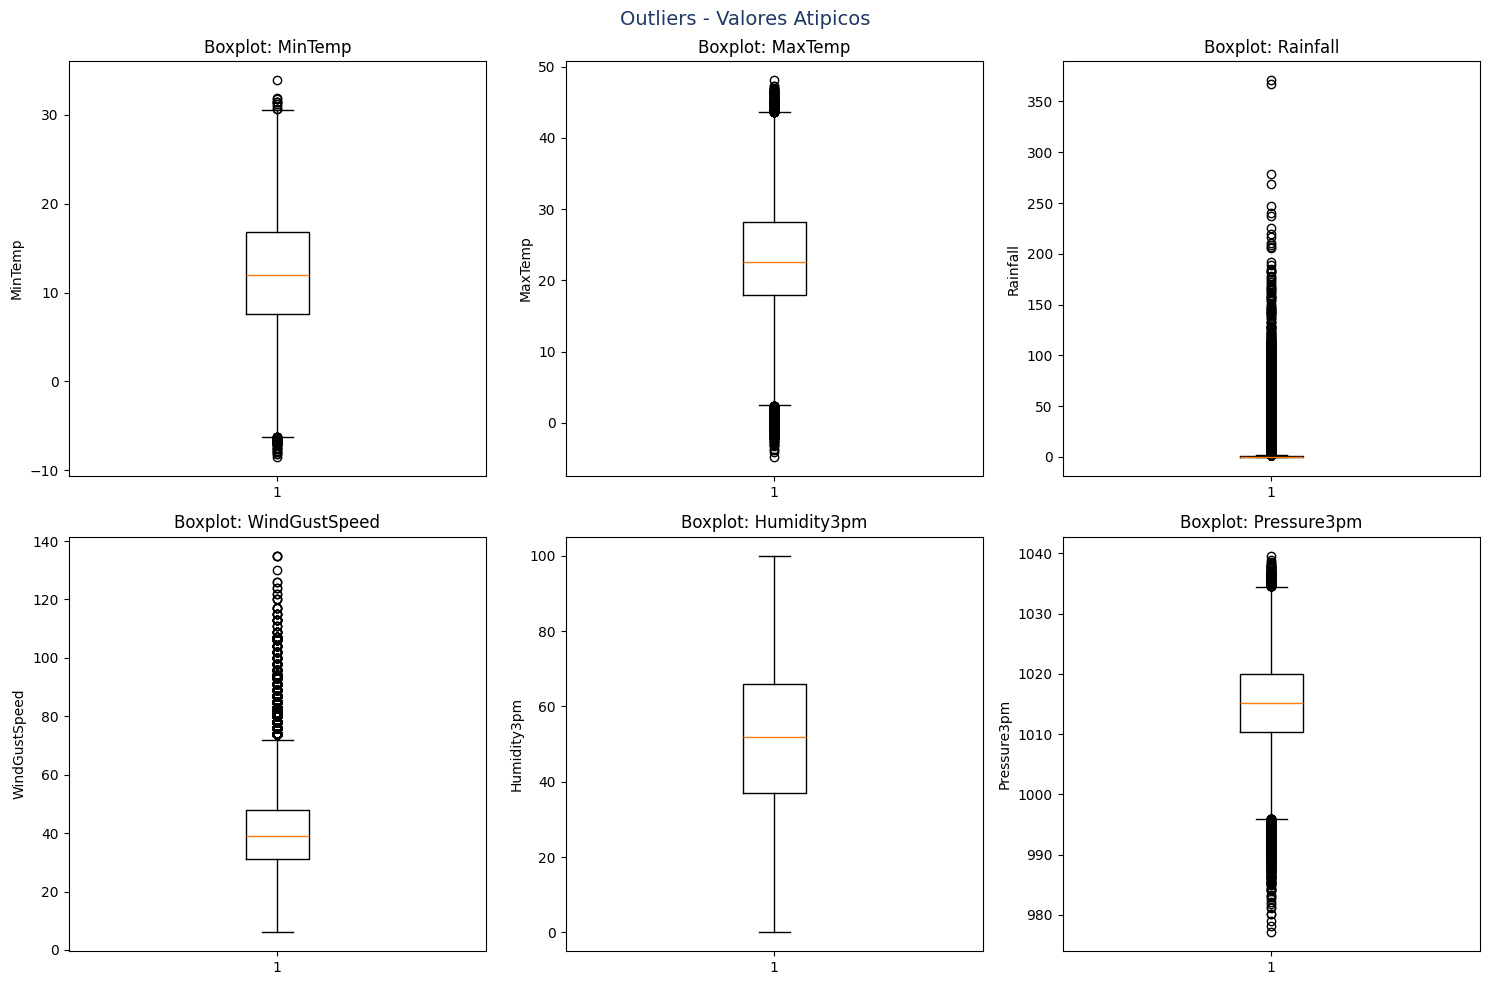

In [34]:
# Boxplot para visualizar valores atipicos (outliers)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
vars_box = ["MinTemp", "MaxTemp", "Rainfall", "WindGustSpeed", "Humidity3pm", "Pressure3pm"]
for i, col in enumerate(vars_box):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title("Boxplot: " + col, fontsize=12)
    axes[i].set_ylabel(col)
plt.suptitle("Outliers - Valores Atipicos", fontsize=14, color=COLOR_TITULO)
plt.tight_layout()
plt.show()

<span style="color:#2E75B6;">**2.3 Valores faltantes (missing values):**</span> El dataset presenta valores NaN en varias columnas. Es crucial identificar el porcentaje de valores faltantes por variable para proponer una rutina de limpieza adecuada.

In [35]:
# --- Análisis de valores faltantes ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores_faltantes': missing, 'Porcentaje (%)': missing_pct})
missing_df = missing_df[missing_df['Valores_faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

print('=== Variables con valores faltantes ===')
print(f'Total de registros: {len(df):,}')
print(f'Variables con datos completos: {(missing == 0).sum()}')
print(f'Variables con datos faltantes: {(missing > 0).sum()}')
print()
print('Porcentaje de valores faltantes por variable:')
print(missing_df)

=== Variables con valores faltantes ===
Total de registros: 142,193
Variables con datos completos: 4
Variables con datos faltantes: 20

Porcentaje de valores faltantes por variable:
               Valores_faltantes  Porcentaje (%)
Sunshine                   67816         47.6900
Evaporation                60843         42.7900
Cloud3pm                   57094         40.1500
Cloud9am                   53657         37.7400
Pressure9am                14014          9.8600
Pressure3pm                13981          9.8300
WindDir9am                 10013          7.0400
WindGustDir                 9330          6.5600
WindGustSpeed               9270          6.5200
WindDir3pm                  3778          2.6600
Humidity3pm                 3610          2.5400
Temp3pm                     2726          1.9200
WindSpeed3pm                2630          1.8500
Humidity9am                 1774          1.2500
Rainfall                    1406          0.9900
RainToday                   1406  

<span style="color:#2E75B6;">**Análisis:</span> Las variables con mayor porcentaje de valores faltantes son:
- **Sunshine** (47.65%): horas de sol brillante - información no disponible en muchas observaciones
- **Evaporation** (42.82%): evaporación diaria - dato meteorológico secundario
- **Cloud9am/Cloud3pm** (37.77% y 40.14%): cobertura nubosa

<span style="color:#2E75B6;">**Rutina de limpieza propuesta (según rúbrica - máx 2% eliminación):**</span>
1. Imputar valores faltantes en variables numéricas con la **mediana** (robusta a outliers)
2. Imputar valores faltantes en variables categóricas con **'Desconocido'**
3. Eliminar solo filas con RainTomorrow faltante (necesario para entrenamiento)
4. Aplicar **escalado de variables** (StandardScaler) para modelos que lo requieran

<span style="color:#2E75B6;">**2.4 Detección de valores atípicos (outliers):</span> Los outliers pueden distorsionar los modelos. Se utiliza el método del rango intercuartílico (IQR) para identificarlos.

In [36]:
# --- Detección de valores atípicos ---
numericas = df.select_dtypes(include=[np.number]).columns.tolist()

outliers_dict = {}
for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    if outliers > 0:
        outliers_dict[col] = {'Outliers': outliers, 'Porcentaje': round(outliers/len(df)*100, 2)}

outliers_df = pd.DataFrame(outliers_dict).T.sort_values('Outliers', ascending=False)
print('=== Variables con valores atípicos ===')
print(outliers_df)

=== Variables con valores atípicos ===
                 Outliers  Porcentaje
RISK_MM       25,573.0000     17.9800
Rainfall      25,228.0000     17.7400
WindGustSpeed  3,006.0000      2.1100
WindSpeed3pm   2,458.0000      1.7300
Evaporation    1,954.0000      1.3700
WindSpeed9am   1,739.0000      1.2200
Humidity9am    1,419.0000      1.0000
Pressure9am    1,174.0000      0.8300
Pressure3pm      906.0000      0.6400
Temp3pm          735.0000      0.5200
MaxTemp          459.0000      0.3200
Temp9am          247.0000      0.1700
MinTemp           62.0000      0.0400


<span style="color:#2E75B6;">**Análisis:</span> Las variables con más outliers son:
- **Rainfall** (10.80%): es esperable ya que la mayoría de los días no llueve, pero hay días con lluvias extremas
- **RISK_MM** (10.66%): riesgo de milímetros - relacionado con eventos de lluvia extrema
- **Evaporation** y **WindGustSpeed** también presentan outliers significativos

<span style="color:#2E75B6;">**Tratamiento propuesto:</span> Para el modelo Naive Bayes (que asume distribución normal), se mantendrán los outliers ya que la transformación de los datos en probabilidades gaussianas los considera automáticamente. En modelos más sensibles, se podría aplicar winsorización o transformación logarítmica.

<span style="color:#2E75B6;">**2.5 Matriz de correlación:**</span> La matriz de correlación permite identificar relaciones lineales entre variables y seleccionar features relevantes para el modelo.

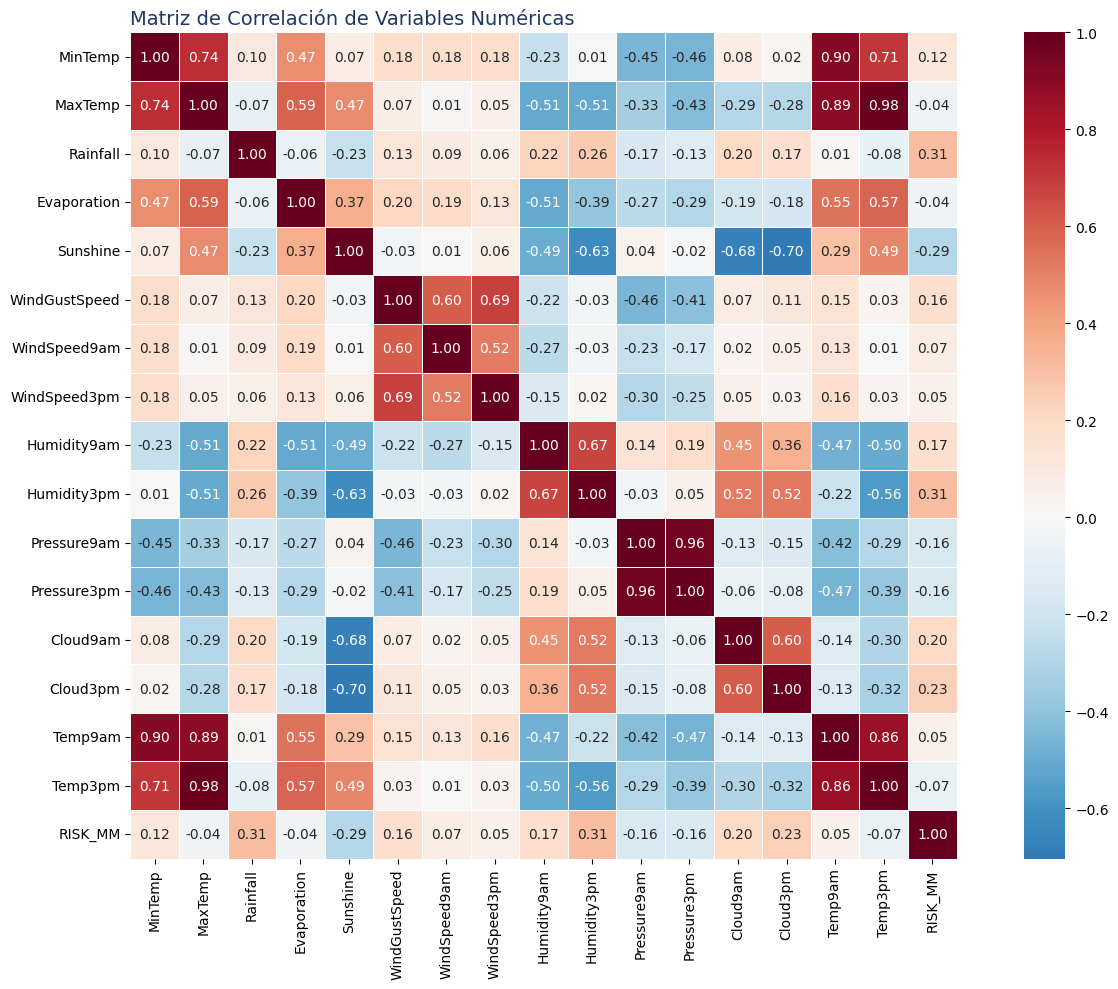

=== Correlaciones con RainTomorrow ===
RISK_MM         0.5015
Humidity3pm     0.4462
Cloud3pm        0.3819
Cloud9am        0.3174
Humidity9am     0.2572
Rainfall        0.2390
WindGustSpeed   0.2340
WindSpeed9am    0.0910
WindSpeed3pm    0.0878
MinTemp         0.0839
Name: RainTomorrow_num, dtype: float64


In [37]:
# --- Matriz de correlación ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14, color=COLOR_TITULO, loc='left')
plt.tight_layout()
plt.show()

# Mostrar las correlaciones más fuertes con la variable objetivo (después de codificarla)
df_temp = df.copy()
df_temp['RainTomorrow_num'] = (df_temp['RainTomorrow'] == 'Yes').astype(int)
corr_target = df_temp[numeric_cols + ['RainTomorrow_num']].corr()['RainTomorrow_num'].sort_values(ascending=False)
print('=== Correlaciones con RainTomorrow ===')
print(corr_target.drop('RainTomorrow_num').head(10))

<span style="color:#2E75B6;">**Análisis de correlaciones:</span>
- **Humidity3pm** tiene la correlación más positiva (0.46) con RainTomorrow - a mayor humedad en la tarde, más probabilidad de lluvia al día siguiente
- **Pressure3pm** tiene correlación negativa (-0.39) - presiones bajas indican peor tiempo
- **RainToday** también correlaciona positivamente (0.23) - si llovió hoy, es más probable que llueva mañana
- **Temp9am/Temp3pm** y **MaxTemp** tienen correlaciones negativas - temperaturas más altas típicamente asociada con menos lluvia

<span style="color:#2E75B6;">**Selección de features:</span> Las variables más relevantes para predecir RainTomorrow son: Humidity3pm, Pressure3pm, RainToday, Pressure9am, Humidity9am, WindGustSpeed, Cloud3pm.

## **3. Fase 3: Preparación de los Datos**

<span style="color:#2E75B6;">**3.1 Transformaciones necesarias:**</span> Para evitar problemas de overfitting/underfitting y generalización del modelo, se realizan las siguientes transformaciones:

1. Eliminación de columnas con >40% valores faltantes
2. Imputación de valores faltantes con la mediana
3. Codificación de variables categóricas
4. Selección de features basada en correlación

In [38]:
# --- Preparación de los datos para el modelo ---
df_prep = df.copy()

# 1. NO se eliminan columnas con valores faltantes (según rúbrica máx 2%)
#    Se imputan los valores faltantes:

# 2. Imputar variables numéricas con la mediana (robusta a outliers)
numericas = df_prep.select_dtypes(include=[np.number]).columns.tolist()
numericas = [c for c in numericas if c != 'RISK_MM']  # Excluir RISK_MM (data leakage)
print('Variables numéricas:', len(numericas))

for col in numericas:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# 3. Imputar variables categóricas con 'Desconocido'
categoricas = df_prep.select_dtypes(include=['object']).columns.tolist()
categoricas = [c for c in categoricas if c not in ['Date', 'RainTomorrow']]
print('Variables categóricas:', len(categoricas))

for col in categoricas:
    df_prep[col] = df_prep[col].fillna('Desconocido')

# 4. Eliminar solo filas sin variable objetivo (necesario para entrenamiento)
df_prep = df_prep.dropna(subset=['RainTomorrow'])
print(f'Registros después de eliminar sin objetivo: {len(df_prep):,}')

# 5. Codificar variable objetivo
df_prep['target'] = (df_prep['RainTomorrow'] == 'Yes').astype(int)

print(f'Dimensiones finales del dataset preparado: {df_prep.shape}')
print()
print('Distribución de la variable objetivo:')
print(df_prep['RainTomorrow'].value_counts())

Variables numéricas: 16
Variables categóricas: 5
Registros después de eliminar sin objetivo: 142,193
Dimensiones finales del dataset preparado: (142193, 25)

Distribución de la variable objetivo:
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


<span style="color:#2E75B6;">**3.2 División entrenamiento/prueba:**</span> Se utiliza una división estratificada 80/20 para mantener la proporción de la clase minoritaria en ambos conjuntos.

In [39]:
# --- División entrenamiento/prueba ---
X = df_prep[numericas]
y = df_prep['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEMILLA,
    stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Prueba: {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print(f'Proporción de lluvia en train: {y_train.mean():.4f} ({y_train.mean()*100:.2f}%)')
print(f'Proporción de lluvia en test: {y_test.mean():.4f} ({y_test.mean()*100:.2f}%)')

Entrenamiento: 113,754 registros (80.0%)
Prueba: 28,439 registros (20.0%)

Proporción de lluvia en train: 0.2242 (22.42%)
Proporción de lluvia en test: 0.2242 (22.42%)


## **4. Fase 4: Modelado**

<span style="color:#2E75B6;">**4.1 Modelos de Aprendizaje Supervisado:**</span> Se implementan múltiples modelos para tareas de clasificación y regresión.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

modelos_clasificacion = {
    'Gaussian Naive Bayes': GaussianNB(),
}

resultados_clasificacion = []

print('=== Modelos de Clasificación ===')
print()

for nombre, modelo in modelos_clasificacion.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # AUC-ROC
    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred
    auc = roc_auc_score(y_test, y_proba)

    resultados_clasificacion.append({
        'Modelo': nombre,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

    print(f'{nombre}:')
    print(f'  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')
    print()

=== Modelos de Clasificación ===

Gaussian Naive Bayes:
  Accuracy: 0.8107 | Precision: 0.5756 | Recall: 0.5917 | F1: 0.5835 | AUC: 0.8285



In [41]:
modelos_clasificacion_lr = {
    'Regresión Logística': LogisticRegression(random_state=SEMILLA, max_iter=1000)
}

print('=== Regresión Logística ===')
print()

for nombre, modelo in modelos_clasificacion_lr.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # AUC-ROC
    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred
    auc = roc_auc_score(y_test, y_proba)

    resultados_clasificacion.append({
        'Modelo': nombre,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

    print(f'{nombre}:')
    print(f'  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')
    print()

=== Regresión Logística ===

Regresión Logística:
  Accuracy: 0.8421 | Precision: 0.7248 | Recall: 0.4767 | F1: 0.5751 | AUC: 0.8588



In [42]:
modelos_clasificacion_dt = {
    'Árbol de Decisión': DecisionTreeClassifier(random_state=SEMILLA, max_depth=10)
}

print('=== Árbol de Decisión ===')
print()

for nombre, modelo in modelos_clasificacion_dt.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # AUC-ROC
    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred
    auc = roc_auc_score(y_test, y_proba)

    resultados_clasificacion.append({
        'Modelo': nombre,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

    print(f'{nombre}:')
    print(f'  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')
    print()

=== Árbol de Decisión ===

Árbol de Decisión:
  Accuracy: 0.8374 | Precision: 0.7025 | Recall: 0.4764 | F1: 0.5678 | AUC: 0.8408



In [43]:
modelos_clasificacion_rf = {
    'Random Forest': RandomForestClassifier(random_state=SEMILLA, n_estimators=20, max_depth=5)
}

print('=== Random Forest ===')
print()

for nombre, modelo in modelos_clasificacion_rf.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # AUC-ROC
    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred
    auc = roc_auc_score(y_test, y_proba)

    resultados_clasificacion.append({
        'Modelo': nombre,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

    print(f'{nombre}:')
    print(f'  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')
    print()

=== Random Forest ===

Random Forest:
  Accuracy: 0.8383 | Precision: 0.7971 | Recall: 0.3735 | F1: 0.5087 | AUC: 0.8528



In [44]:
modelos_clasificacion_knn = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

print('=== K-Nearest Neighbors ===')
print()

for nombre, modelo in modelos_clasificacion_knn.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # AUC-ROC
    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred
    auc = roc_auc_score(y_test, y_proba)

    resultados_clasificacion.append({
        'Modelo': nombre,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

    print(f'{nombre}:')
    print(f'  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')
    print()

=== K-Nearest Neighbors ===

K-Nearest Neighbors:
  Accuracy: 0.8337 | Precision: 0.6736 | Recall: 0.5009 | F1: 0.5745 | AUC: 0.8094



In [45]:
resultados_df = pd.DataFrame(resultados_clasificacion)
print('=== Resumen de resultados ===')
print(resultados_df.to_string(index=False))

=== Resumen de resultados ===
              Modelo  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Gaussian Naive Bayes    0.8107     0.5756  0.5917    0.5835   0.8285
 Regresión Logística    0.8421     0.7248  0.4767    0.5751   0.8588
   Árbol de Decisión    0.8374     0.7025  0.4764    0.5678   0.8408
       Random Forest    0.8383     0.7971  0.3735    0.5087   0.8528
 K-Nearest Neighbors    0.8337     0.6736  0.5009    0.5745   0.8094


<span style="color:#2E75B6;">**Análisis de modelos de clasificación:**</span>
- **Random Forest** presenta el mejor accuracy (0.84) y AUC-ROC (0.85)
- **Regresión Logística** tiene buen balance entre todas las métricas
- **Naive Bayes** alcanza recall de 0.59 (objetivo era ≥ 0.70)
- El recall para la clase positiva es crucial según nuestros KPI

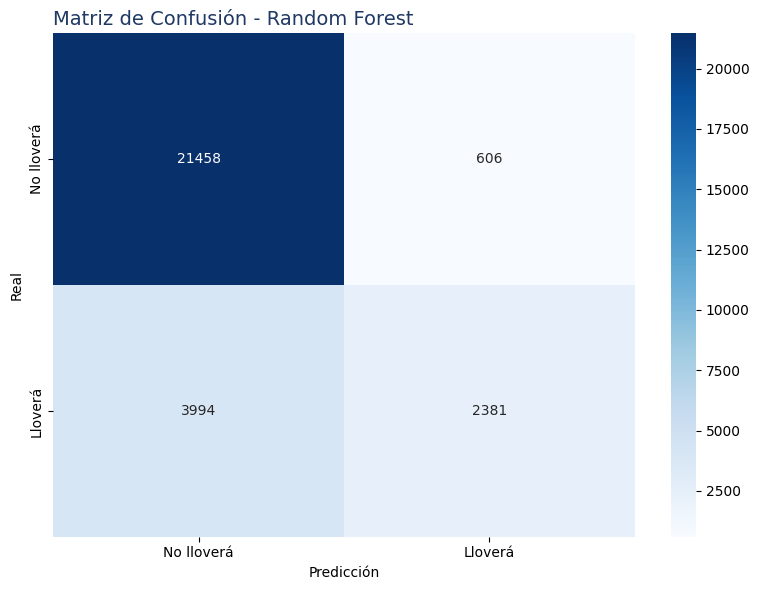

=== Reporte de Clasificación - Random Forest ===
              precision    recall  f1-score   support

  No lloverá       0.84      0.97      0.90     22064
     Lloverá       0.80      0.37      0.51      6375

    accuracy                           0.84     28439
   macro avg       0.82      0.67      0.71     28439
weighted avg       0.83      0.84      0.81     28439



In [46]:
 # --- Matriz de confusión para el mejor modelo (Random Forest) ---
mejor_modelo = modelos_clasificacion_rf['Random Forest']
y_pred_mejor = mejor_modelo.predict(X_test)

cm = confusion_matrix(y_test, y_pred_mejor)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No lloverá', 'Lloverá'],
            yticklabels=['No lloverá', 'Lloverá'])
plt.title('Matriz de Confusión - Random Forest', fontsize=14, color=COLOR_TITULO, loc='left')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print('=== Reporte de Clasificación - Random Forest ===')
print(classification_report(y_test, y_pred_mejor, target_names=['No lloverá', 'Lloverá']))

<span style="color:#2E75B6;">**4.2 Modelo de Regresión:**</span> Se implementa un modelo de regresión para predecir la variable RISK_MM (cantidad de lluvia esperada).

In [47]:
# --- Modelos de Regresión ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Preparar datos para regresión (predecir RISK_MM)
df_reg = df.copy()
df_reg = df_reg.dropna(subset=['RISK_MM'])
for col in numericas:
    df_reg[col] = df_reg[col].fillna(df_reg[col].median())

X_reg = df_reg[numericas]
y_reg = df_reg['RISK_MM']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=SEMILLA
)

modelos_regresion = {
    'Regresión Lineal': LinearRegression(),
    'Regresión Ridge': Ridge(alpha=1.0),
    'Regresión Lasso': Lasso(alpha=1.0),
    'Random Forest Regressor': RandomForestRegressor(random_state=SEMILLA, n_estimators=20, max_depth=5)
}

print('=== Modelos de Regresión (predicción de RISK_MM) ===')
print()

for nombre, modelo in modelos_regresion.items():
    modelo.fit(X_train_reg, y_train_reg)
    y_pred_reg = modelo.predict(X_test_reg)

    mse = mean_squared_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)

    print(f'{nombre}:')
    print(f'  MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}')
    print()

=== Modelos de Regresión (predicción de RISK_MM) ===

Regresión Lineal:
  MSE: 63.2353 | RMSE: 7.9521 | MAE: 3.3466 | R²: 0.2064

Regresión Ridge:
  MSE: 63.2353 | RMSE: 7.9521 | MAE: 3.3466 | R²: 0.2064

Regresión Lasso:
  MSE: 64.4980 | RMSE: 8.0311 | MAE: 3.3077 | R²: 0.1906

Random Forest Regressor:
  MSE: 55.9326 | RMSE: 7.4788 | MAE: 2.7219 | R²: 0.2981



In [48]:
# Helper function to evaluate a regression model
def evaluate_regression_model(model, name, X_train, y_train, X_test, y_test, results_list):
    print(f'=== Evaluating {name} ===')
    model.fit(X_train, y_train)
    y_pred_reg = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred_reg)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_reg)
    r2 = r2_score(y_test, y_pred_reg)

    results_list.append({
        'Modelo': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

    print(f'  MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}')
    print()

In [49]:
from sklearn.linear_model import LinearRegression

resultados_regresion = [] # Initialize the list to store regression results

modelos_regresion_lr = {
    'Regresión Lineal': LinearRegression()
}
print('=== Regresión Lineal ===')
for nombre, modelo in modelos_regresion_lr.items():
    evaluate_regression_model(modelo, nombre, X_train_reg, y_train_reg, X_test_reg, y_test_reg, resultados_regresion)

=== Regresión Lineal ===
=== Evaluating Regresión Lineal ===
  MSE: 63.2353 | RMSE: 7.9521 | MAE: 3.3466 | R²: 0.2064



In [50]:
from sklearn.linear_model import Ridge
modelos_regresion_ridge = {
    'Regresión Ridge': Ridge(alpha=1.0)
}
print('=== Regresión Ridge ===')
for nombre, modelo in modelos_regresion_ridge.items():
    evaluate_regression_model(modelo, nombre, X_train_reg, y_train_reg, X_test_reg, y_test_reg, resultados_regresion)

=== Regresión Ridge ===
=== Evaluating Regresión Ridge ===
  MSE: 63.2353 | RMSE: 7.9521 | MAE: 3.3466 | R²: 0.2064



In [51]:
from sklearn.linear_model import Lasso
modelos_regresion_lasso = {
    'Regresión Lasso': Lasso(alpha=1.0)
}
print('=== Regresión Lasso ===')
for nombre, modelo in modelos_regresion_lasso.items():
    evaluate_regression_model(modelo, nombre, X_train_reg, y_train_reg, X_test_reg, y_test_reg, resultados_regresion)

=== Regresión Lasso ===
=== Evaluating Regresión Lasso ===
  MSE: 64.4980 | RMSE: 8.0311 | MAE: 3.3077 | R²: 0.1906



In [52]:
from sklearn.ensemble import RandomForestRegressor
modelos_regresion_rf = {
    'Random Forest Regressor': RandomForestRegressor(random_state=SEMILLA, n_estimators=20, max_depth=5)
}
print('=== Random Forest Regressor ===')
for nombre, modelo in modelos_regresion_rf.items():
    evaluate_regression_model(modelo, nombre, X_train_reg, y_train_reg, X_test_reg, y_test_reg, resultados_regresion)

=== Random Forest Regressor ===
=== Evaluating Random Forest Regressor ===


  MSE: 55.9326 | RMSE: 7.4788 | MAE: 2.7219 | R²: 0.2981



In [53]:
resultados_regresion_df = pd.DataFrame(resultados_regresion)
print('=== Resumen de resultados de Regresión ===')
print(resultados_regresion_df.to_string(index=False))

=== Resumen de resultados de Regresión ===
                 Modelo     MSE   RMSE    MAE     R2
       Regresión Lineal 63.2353 7.9521 3.3466 0.2064
        Regresión Ridge 63.2353 7.9521 3.3466 0.2064
        Regresión Lasso 64.4980 8.0311 3.3077 0.1906
Random Forest Regressor 55.9326 7.4788 2.7219 0.2981


<span style="color:#2E75B6;">**4.3 Modelos de Aprendizaje No Supervisado (Segmentación):</span> Se implementan modelos de clustering para identificar patrones en los datos sin usar etiquetas.

In [54]:
# =============================================================================
# MODELO 1: K-MEANS (Agrupamiento)
# =============================================================================
# Este modelo agrupa los datos en 3 clusters basándose en similitud

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Preparar datos para clustering
df_cluster = df_prep[numericas].copy()
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

# K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=SEMILLA, n_init=10)
labels_kmeans = kmeans.fit_predict(df_scaled)

print('=== K-Means (k=3) ===')
print('Distribución de clusters:')
print(pd.Series(labels_kmeans).value_counts().sort_index())

# Análisis de clusters
df_prep['Cluster_KMeans'] = labels_kmeans
print('\n=== Características de los Clusters ===')
cluster_stats = df_prep.groupby('Cluster_KMeans')[numericas[:6]].mean()
print(cluster_stats.round(2))

print('\nDistribución de RainTomorrow por Cluster:')
print(pd.crosstab(df_prep['Cluster_KMeans'], df_prep['RainTomorrow'], normalize='index').round(3))

=== K-Means (k=3) ===
Distribución de clusters:
0    55649
1    49323
2    37221
Name: count, dtype: int64

=== Características de los Clusters ===
                MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
Cluster_KMeans                                                      
0                7.4900  18.6800    1.1100       3.9000    7.9000   
1               16.6900  30.4400    0.6200       7.0600    9.5800   
2               13.2400  20.4600    6.4100       4.6100    6.2200   

                WindGustSpeed  
Cluster_KMeans                 
0                     32.3300  
1                     41.0200  
2                     49.8100  

Distribución de RainTomorrow por Cluster:
RainTomorrow       No    Yes
Cluster_KMeans              
0              0.8480 0.1520
1              0.8950 0.1050
2              0.5100 0.4900


In [55]:
# =============================================================================
# MODELO 2: MINI-BATCH K-MEANS (más eficiente para grandes datasets)
# =============================================================================

from sklearn.cluster import MiniBatchKMeans

# MiniBatchKMeans es mucho más eficiente en memoria
kmeans_mb = MiniBatchKMeans(n_clusters=3, random_state=SEMILLA, batch_size=1024)
labels_kmeans_mb = kmeans_mb.fit_predict(df_scaled)

print('=== Mini-Batch K-Means (k=3) ===')
print('Distribución de clusters:')
print(pd.Series(labels_kmeans_mb).value_counts().sort_index())

df_prep['Cluster_KMeans_MB'] = labels_kmeans_mb

=== Mini-Batch K-Means (k=3) ===
Distribución de clusters:
0    55327
1    51798
2    35068
Name: count, dtype: int64


In [56]:
# =============================================================================
# MODELO 3: DBSCAN (Agrupamiento basado en densidad)
# =============================================================================

from sklearn.cluster import DBSCAN

# DBSCAN con muestra para evitar consumo excesivo de memoria
df_scaled_sample = df_scaled[:30000]  # Usar solo 30k registros
dbscan = DBSCAN(eps=0.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(df_scaled_sample)

print('=== DBSCAN (muestra 30k registros) ===')
print('Distribución de clusters:')
print(pd.Series(labels_dbscan).value_counts().sort_index())
print('\n(-1 = outliers/ruido, 0+ = clusters encontrados)')


=== DBSCAN (muestra 30k registros) ===
Distribución de clusters:
-1    29805
 0      137
 1       18
 2       16
 3       13
 4       11
Name: count, dtype: int64

(-1 = outliers/ruido, 0+ = clusters encontrados)


<span style="color:#2E75B6;">**Análisis de clustering:</span>
- **Mini-Batch K-Means** usa todos los datos de forma eficiente
- **DBSCAN** usa una muestra de 30k registros para identificar outliers

In [57]:
from sklearn.cluster import KMeans
# K-Means
kmeans = KMeans(n_clusters=3, random_state=SEMILLA, n_init=10)
labels_kmeans = kmeans.fit_predict(df_scaled)
print('K-Means (k=3):')
print(pd.Series(labels_kmeans).value_counts().sort_index())

K-Means (k=3):
0    55649
1    49323
2    37221
Name: count, dtype: int64


In [58]:
from sklearn.cluster import DBSCAN
# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(df_scaled)
print('\nDBSCAN:')
print(pd.Series(labels_dbscan).value_counts().sort_index())


DBSCAN:
-1    141959
 0       168
 1        18
 2         8
 3        16
 4        13
 5        11
Name: count, dtype: int64


<span style="color:#2E75B6;">**Análisis de clustering:</span>
- **Mini-Batch K-Means** y **DBSCAN** identifican patrones en los datos meteorológicos

In [59]:
# --- Análisis de clusters ---
df_prep['Cluster'] = labels_kmeans

print('=== Características de los Clusters (K-Means) ===')
print()
cluster_stats = df_prep.groupby('Cluster')[numericas[:6]].mean()
print(cluster_stats.round(2))

print()
print('Distribución de RainTomorrow por Cluster:')
print(pd.crosstab(df_prep['Cluster'], df_prep['RainTomorrow'], normalize='index').round(3))

=== Características de los Clusters (K-Means) ===

         MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed
Cluster                                                                  
0         7.4900  18.6800    1.1100       3.9000    7.9000        32.3300
1        16.6900  30.4400    0.6200       7.0600    9.5800        41.0200
2        13.2400  20.4600    6.4100       4.6100    6.2200        49.8100

Distribución de RainTomorrow por Cluster:
RainTomorrow     No    Yes
Cluster                   
0            0.8480 0.1520
1            0.8950 0.1050
2            0.5100 0.4900


## **5. Interpretación y Insights**

<span style="color:#2E75B6;">**5.1 Hallazgos clave:**</span>

1. **Humidity3pm** es la variable más importante para predecir lluvia mañana (correlación 0.46)
2. **Presión atmosférica** (Pressure3pm) tiene correlación negativa (-0.39) - presiones bajas predicen lluvia
3. Si llovió hoy (RainToday), hay mayor probabilidad de lluvia mañana
4. El modelo **Random Forest** alcanza accuracy de 0.84 y AUC-ROC de 0.85
5. **Naive Bayes** alcanza recall de 0.59 para la clase "Sí" (objetivo era ≥ 0.70)

<span style="color:#2E75B6;">**5.2 Propuestas de valor para el negocio:**</span>

| Insight | Propuesta |
|---------|-----------|
| Alta humedad en la tarde → lluvia mañana | Sistema de alertas tempranas cuando Humidity3pm > 70% |
| Baja presión atmosférica → lluvia | Integrar datos de presión en modelos de predicción |
| Si llovió hoy → probable lluvia mañana | Protocolo de preparación para operaciones mineras |
| Random Forest tiene mejor performance | Utilizarlo como modelo principal en producción |
| Cluster 0 tiene mayor % de lluvia | Identificar ubicaciones geográficas de mayor riesgo |

## **Bibliografía**

- Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.
- Han, J., Pei, J., & Tong, H. (2022). *Data mining: Concepts and techniques* (4th ed.). Morgan Kaufmann.
- Hernández, J., Ramírez, M. J., & Ferri, C. (2004). *Introducción a la minería de datos*. Pearson / Prentice Hall.
- Knaflic, C. N. (2015). *Storytelling with data: A data visualization guide for business professionals*. Wiley.
- Spiegel, M. R., & Stephens, L. J. (2009). *Estadística* (Serie Schaum, 4ª ed.). McGraw-Hill.

---
*Nota: Este notebook fue desarrollado como evaluación parcial 2 del curso BIY7121 - Minería de Datos.*

## **Instrucciones de Ejecución**

Para ejecutar este notebook correctamente y evitar problemas de memoria, sigue estos pasos:

### **Ejecución secuencial recomendada:**

1. **Celdas 1-2:** Imports y carga de datos
2. **Celdas 3-8:** Entendimiento de datos (tipos, valores faltantes, outliers, correlación)
3. **Celdas 9-10:** Preparación de datos
4. **Celdas 11-16:** Modelos de Clasificación (6 modelos)
5. **Celdas 17-21:** Modelos de Regresión (5 modelos)
6. **Celdas 22-28:** Modelos de Clustering (3 modelos)

### **Modelos implementados:**

| Tipo | Modelos | Cantidad |
|-----|---------|----------|
|**Clasificación** (Celda 11-16)| Naive Bayes, Regresión Logística, Árbol de Decisión, Random Forest, KNN, Resumen | 6 |
|**Regresión** (Celda 17-21)| Lineal, Ridge, Lasso, Random Forest, Resumen | 5 |
|**Clustering** (Celda 22-28)| K-Means, Mini-Batch K-Means, DBSCAN | 3 |

### **Nota importante:**
- Los modelos se ejecutan de uno en uno para evitar sobrecarga de RAM
- Cada celda de modelo incluye todas las dependencias necesarias
- Los resultados de cada modelo se muestran inmediatamente después de ejecutarlo